In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from os import read
from google.colab import drive
drive.mount('/content/drive')

df = "/content/drive/MyDrive/Colab Notebooks/Initial_Modeling_Dataset.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
def build_retention_curve(data):

    tenure = data["time_spend_company"]
    event = data["attrition_flag"]

    max_t = int(tenure.max())
    times = np.arange(0, max_t + 1)

    retention = []
    survival = 1.0

    for t in times:
        at_risk = (tenure >= t).sum()
        events = ((tenure == t) & (event == 1)).sum()

        if at_risk > 0:
            hazard = events / at_risk
            survival = survival * (1 - hazard)

        retention.append(survival)

    return times, retention

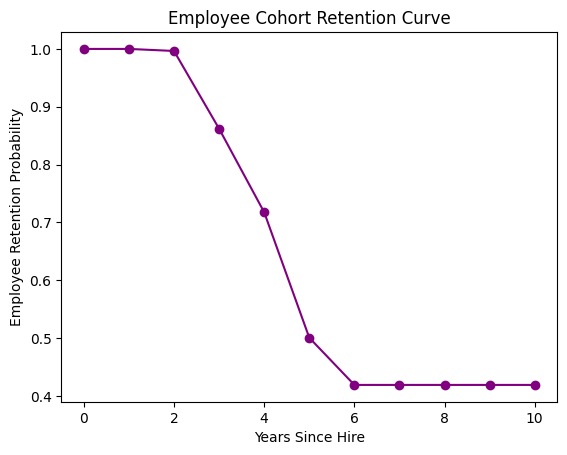

In [18]:
data_df = pd.read_csv(df)
times, retention = build_retention_curve(data_df)

plt.figure()

plt.plot(times, retention, marker="o", color='purple')

plt.xlabel("Years Since Hire")
plt.ylabel("Employee Retention Probability")
plt.title("Employee Cohort Retention Curve")

plt.show()

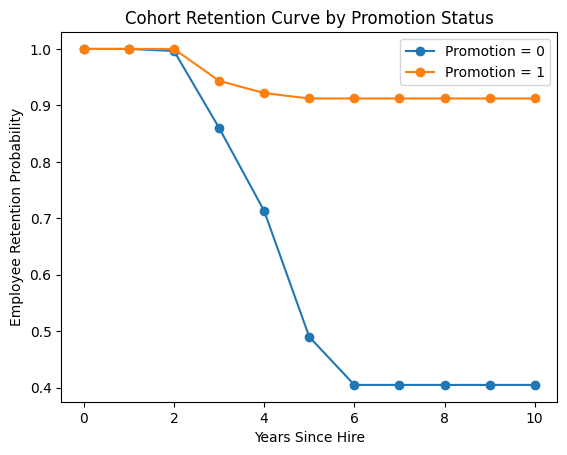

In [10]:
plt.figure()

for promo in sorted(data_df["promotion_last_5years"].unique()):

    subset = data_df[data_df["promotion_last_5years"] == promo]

    times, retention = build_retention_curve(subset)

    plt.plot(times, retention, marker="o", label=f"Promotion = {promo}")

plt.xlabel("Years Since Hire")
plt.ylabel("Employee Retention Probability")
plt.title("Cohort Retention Curve by Promotion Status")

plt.legend()

plt.show()

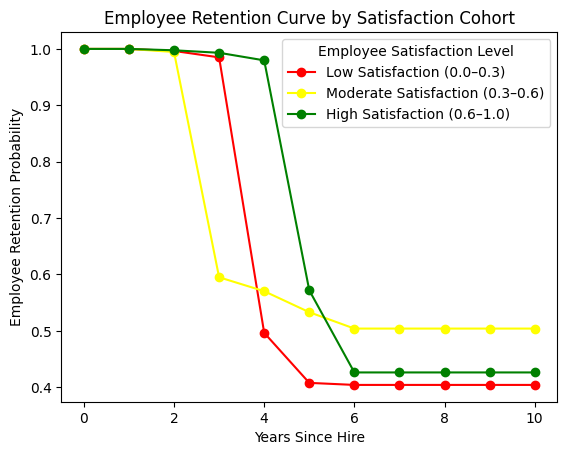

In [19]:
# Create labeled satisfaction cohorts
data_df["satisfaction_cohort"] = pd.cut(
    data_df["satisfaction_level"],
    bins=[0, 0.3, 0.6, 1],
    labels=[
        "Low Satisfaction (0.0–0.3)",
        "Moderate Satisfaction (0.3–0.6)",
        "High Satisfaction (0.6–1.0)"
    ]
)

plt.figure()

# Define color mapping for cohorts
color_map = {
    "Low Satisfaction (0.0–0.3)": "red",
    "Moderate Satisfaction (0.3–0.6)": "yellow",
    "High Satisfaction (0.6–1.0)": "green"
}

for cohort, subset in data_df.groupby("satisfaction_cohort", observed=False):
    times, retention = build_retention_curve(subset)
    # Get the color from the map, default to black if not found
    plot_color = color_map.get(cohort, "black")
    plt.plot(times, retention, marker="o", label=cohort, color=plot_color)

plt.xlabel("Years Since Hire")
plt.ylabel("Employee Retention Probability")
plt.title("Employee Retention Curve by Satisfaction Cohort")

plt.legend(title="Employee Satisfaction Level")

plt.show()